# Testing Model Performance
### Subliminal trials before entire epoch is run

In [107]:
from __future__ import annotations

import re
import json
import inspect
import shutil
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# ----------------------------
# Run Controls (cell is intentionally config-only)
# ----------------------------
BIRDS = ["DavidBowie", "Endive"]
SNAPSHOTS_TARGET = [100, 125, 150]
NUMFRAMES_TARGET = [200, 400, 800, 1400]

RUN_CROSS_TRIAL = True
RUN_WITHIN_TRIAL = True
SKIP_MISSING_SNAPSHOTS = True

RUN_BUILD_CLIPS = True
RUN_INFERENCE = True
RUN_EVALUATION = True

ALLOW_HIGH_LEVEL_FALLBACK = True
OVERWRITE_CLIPS = False
OVERWRITE_INFERENCE = False

VIDEO_CODEC = "MJPG"
VIDEO_FPS = 500.0

THRESHOLD_MODE = "rmse"  # rmse|fixed
FIXED_THRESHOLD_PX = 8.0

NOTEBOOK_DIR = Path.cwd()
TESTING_ROOT = NOTEBOOK_DIR.parent
DEEPLABCUT_ROOT = TESTING_ROOT / "DeepLabCut"

print(f"Testing root: {TESTING_ROOT}")
print(f"DeepLabCut root: {DEEPLABCUT_ROOT}")

Testing root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing
DeepLabCut root: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut


In [3]:
# ----------------------------
# Pair Mode Expansion
# ----------------------------
TRIAL_MAP = {
    "DavidBowie": [15, 17],
    "Endive": [32],
}


def build_trial_pairs(bird: str) -> list[tuple[int, int]]:
    trials = TRIAL_MAP.get(bird, [])
    pairs: list[tuple[int, int]] = []

    if RUN_CROSS_TRIAL and len(trials) >= 2:
        for t in trials:
            for e in trials:
                if t != e:
                    pairs.append((t, e))

    if RUN_WITHIN_TRIAL:
        for t in trials:
            if t == 17:
                continue
            else:
                pairs.append((t, t))

    # deterministic order + unique
    pairs = sorted(set(pairs), key=lambda x: (x[0], x[1]))
    return pairs


all_pair_rows: list[dict[str, Any]] = []
for bird in BIRDS:
    for train_trial, eval_trial in build_trial_pairs(bird):
        if train_trial == 17 and eval_trial == 17:
            print(f"Skipping pair {bird} T{train_trial}-T{eval_trial} due to missing snapshots")
            continue
        else:
            all_pair_rows.append(
                {
                    "bird": bird,
                    "train_trial": train_trial,
                    "eval_trial": eval_trial,
                    "pair_slug": f"TrainT{train_trial}_EvalT{eval_trial}",
                }
            )
    

pair_df = pd.DataFrame(all_pair_rows)
pair_df = pair_df[~((pair_df['train_trial'] == 17) & (pair_df['eval_trial'] == 17))]  # exclude T17-T17 due to missing snapshots
display(pair_df)

,bird,train_trial,eval_trial,pair_slug
0,DavidBowie,15,15,TrainT15_EvalT15
1,DavidBowie,15,17,TrainT15_EvalT17
2,DavidBowie,17,15,TrainT17_EvalT15
3,Endive,32,32,TrainT32_EvalT32


In [ ]:

from pathlib import Path
from typing import Iterable
import re
from PIL import Image

def extract_images_by_indices(
    source_dir: str | Path,
    output_dir: str | Path,
    indices: Iterable[int],
    one_based: bool = True,
) -> dict:
    """
    Copy selected images from source_dir into output_dir as JPGs.

    Args:
        source_dir: Folder containing images.
        output_dir: Folder to create/write selected images.
        indices: Frame indices to extract.
        one_based: True if indices start at 1 (default), else 0-based.

    Returns:
        Dict with written files and skipped indices.
    """
    source_dir = Path(source_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    def sort_key(p: Path):
        m = re.search(r"(\d+)$", p.stem)
        frame_num = int(m.group(1)) if m else 10**12
        return (frame_num, p.name.lower())

    images = sorted(
        [p for p in source_dir.iterdir() if p.is_file() and p.suffix.lower() in image_exts],
        key=sort_key,
    )

    written = []
    skipped = []

    for idx in sorted(set(int(i) for i in indices)):
        i = idx - 1 if one_based else idx
        if i < 0 or i >= len(images):
            skipped.append(idx)
            continue

        src = images[i]
        dst = output_dir / f"{idx:04d}.jpg"

        with Image.open(src) as im:
            im.convert("RGB").save(dst, format="JPEG", quality=95)

        written.append(str(dst))

    return {
        "source_count": len(images),
        "requested_count": len(set(int(i) for i in indices)),
        "written_count": len(written),
        "skipped_indices": skipped,
        "written_files": written,
    }

In [ ]:
result = extract_images_by_indices(
    source_dir=r"C:\path\to\cam1",
    output_dir=r"C:\path\to\selected\cam1",
    indices=[1, 5, 12, 100],
    one_based=True,
)
print(result)

In [4]:
# ----------------------------
# Shared Helpers: Naming + Discovery
# ----------------------------


def pair_slug(train_trial: int, eval_trial: int) -> str:
    return f"TrainT{train_trial}_EvalT{eval_trial}"


def bird_root(bird: str) -> Path:
    return DEEPLABCUT_ROOT / bird


def batch_root(bird: str) -> Path:
    return bird_root(bird) / "ExperimentEval" / "UFBatch"


def model_build_root(bird: str) -> Path:
    return bird_root(bird) / "ModelBuildExperiments"


def discover_model_configs_for_trial(bird: str, train_trial: int) -> list[Path]:
    root = model_build_root(bird)
    if not root.exists():
        return []

    configs = sorted(root.glob(f"{bird}_n*_T{train_trial}/Canari-Tyler-*/config.yaml"))
    return [c for c in configs if c.exists()]


def extract_numframes_from_model_dir(model_dir_name: str) -> int | None:
    m = re.search(r"_n(\d+)_T\d+$", model_dir_name)
    return int(m.group(1)) if m else None

In [5]:
# ----------------------------
# Shared Helpers: Eval Assets + Clips
# ----------------------------


def resolve_eval_train_dir(bird: str, eval_trial: int) -> Path:
    d = bird_root(bird) / f"TrainingData_T{eval_trial}"
    if d.exists():
        return d
    raise FileNotFoundError(f"Could not find eval training dir for {bird} T{eval_trial}: {d}")


def resolve_cam_dir(eval_train_dir: Path, eval_trial: int, cam_idx: int) -> Path:
    expected = eval_train_dir / f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"
    if expected.exists():
        return expected
    matches = sorted(eval_train_dir.rglob(f"Cam{cam_idx}_Img00UND_Trial{eval_trial}"))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"Missing Cam{cam_idx} eval image dir under {eval_train_dir}")


def resolve_truth_csv(eval_train_dir: Path, eval_trial: int) -> Path:
    candidates = sorted(eval_train_dir.rglob(f"*Trial{eval_trial}*.csv"))
    if not candidates:
        candidates = sorted(eval_train_dir.rglob("*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No truth CSV under {eval_train_dir}")
    return candidates[0]


def parse_frame_number_from_stem(stem: str) -> int | None:
    m = re.search(r"(\d+)(?!.*\d)", stem)
    return int(m.group(1)) if m else None


def collect_images(image_dir: Path) -> list[Path]:
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
    images = [p for p in image_dir.iterdir() if p.is_file() and p.suffix.lower() in exts]
    return sorted(images, key=lambda p: (parse_frame_number_from_stem(p.stem) is None, parse_frame_number_from_stem(p.stem) or 0, p.name))

In [6]:
# ----------------------------
# Shared Helpers: Video Build
# ----------------------------


def build_video_from_images(
    image_paths: list[Path],
    out_video: Path,
    fps: float = VIDEO_FPS,
    codec: str = VIDEO_CODEC,
    overwrite: bool = False,
) -> dict[str, Any]:
    try:
        import cv2
    except Exception as exc:
        raise ImportError("OpenCV (cv2) is required to build evaluation clips.") from exc

    if not image_paths:
        raise ValueError(f"No image paths provided for {out_video}")

    if out_video.exists() and not overwrite:
        frame_lookup = [parse_frame_number_from_stem(p.stem) or (i + 1) for i, p in enumerate(image_paths)]
        return {"video": out_video, "status": "reused", "n_frames": len(frame_lookup), "frame_lookup": frame_lookup}

    first = cv2.imread(str(image_paths[0]))
    if first is None:
        raise FileNotFoundError(f"Could not read first image: {image_paths[0]}")

    h, w = first.shape[:2]
    out_video.parent.mkdir(parents=True, exist_ok=True)
    writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*codec), float(fps), (w, h))

    n_written = 0
    frame_lookup: list[int] = []
    for img_path in image_paths:
        frame = cv2.imread(str(img_path))
        if frame is None:
            continue
        if frame.shape[:2] != (h, w):
            frame = cv2.resize(frame, (w, h))
        writer.write(frame)
        n_written += 1
        frame_lookup.append(parse_frame_number_from_stem(img_path.stem) or n_written)

    writer.release()
    return {"video": out_video, "status": "created", "n_frames": n_written, "frame_lookup": frame_lookup}

In [7]:
# ----------------------------
# Discovery Execution: Bird/Pair/Model Inventory
# ----------------------------

inventory_rows: list[dict[str, Any]] = []

for bird in BIRDS:
    for train_trial, eval_trial in build_trial_pairs(bird):
        cfgs = discover_model_configs_for_trial(bird, train_trial)
        eval_dir = resolve_eval_train_dir(bird, eval_trial)
        truth_csv = resolve_truth_csv(eval_dir, eval_trial)

        for cfg in cfgs:
            model_dir = cfg.parent.parent.name
            numframes = extract_numframes_from_model_dir(model_dir)
            if numframes is None or (NUMFRAMES_TARGET and numframes not in NUMFRAMES_TARGET):
                continue

            inventory_rows.append(
                {
                    "bird": bird,
                    "train_trial": train_trial,
                    "eval_trial": eval_trial,
                    "pair_slug": pair_slug(train_trial, eval_trial),
                    "model_dir": model_dir,
                    "numframes": numframes,
                    "config_path": str(cfg),
                    "eval_dir": str(eval_dir),
                    "truth_csv": str(truth_csv),
                }
            )

inventory_df = pd.DataFrame(inventory_rows).sort_values(["bird", "train_trial", "eval_trial", "numframes"]).reset_index(drop=True)
print(f"Discovered inventory rows: {len(inventory_df)}")
display(inventory_df.head(50))

Discovered inventory rows: 14


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,config_path,eval_dir,truth_csv
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
3,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
4,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n400_T15,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
5,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n800_T15,800,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
6,DavidBowie,17,15,TrainT17_EvalT15,DavidBowie_n200_T17,200,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
7,DavidBowie,17,15,TrainT17_EvalT15,DavidBowie_n400_T17,400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
8,DavidBowie,17,15,TrainT17_EvalT15,DavidBowie_n800_T17,800,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...
9,DavidBowie,17,15,TrainT17_EvalT15,DavidBowie_n1400_T17,1400,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...


In [165]:
for i in range(len(inventory_df)):
    print(inventory_df['truth_csv'][i])

c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T15\CollectedData_Trial15_DB.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\TrainingData_T17\2Dpoints_2025_08_25_DavidBowie_Subset_Trial17_UND_matches.csv
c:\Users\Salle-Cineradio\Documents\MachineLearnin

In [8]:
# ----------------------------
# Snapshot Helpers
# ----------------------------


def discover_snapshot_files(config_path: Path) -> list[Path]:
    model_root = config_path.parent
    candidates = sorted(model_root.rglob("snapshot-*.pt"))
    if candidates:
        return candidates
    # fallback pattern used in older layouts
    return sorted(model_root.rglob("*snapshot*.pt"))


def parse_snapshot_number(snapshot_path: Path) -> int | None:
    m = re.search(r"snapshot[-_](\d+)", snapshot_path.stem)
    return int(m.group(1)) if m else None


def select_snapshot_files(snapshot_files: list[Path], targets: list[int]) -> tuple[dict[int, Path], list[int]]:
    by_num: dict[int, Path] = {}
    for s in snapshot_files:
        n = parse_snapshot_number(s)
        if n is not None and n not in by_num:
            by_num[n] = s

    missing = [n for n in targets if n not in by_num]
    selected = {n: by_num[n] for n in targets if n in by_num}
    return selected, missing

In [49]:
# ----------------------------
# Snapshot Availability Table
# ----------------------------

snapshot_rows: list[dict[str, Any]] = []

for _, row in inventory_df.iterrows():
    cfg = Path(row["config_path"])
    files = discover_snapshot_files(cfg) 
    selected, missing = select_snapshot_files(files, SNAPSHOTS_TARGET)

    for n in SNAPSHOTS_TARGET:
        snapshot_rows.append(
            {
                "bird": row["bird"],
                "train_trial": int(row["train_trial"]),
                "eval_trial": int(row["eval_trial"]),
                "pair_slug": row["pair_slug"],
                "model_dir": row["model_dir"],
                "numframes": int(row["numframes"]),
                "snapshot_num": n,
                "found": n in selected,
                "snapshot_path": str(selected[n]) if n in selected else None,
                "status": "missing" if n in missing else "ready",
            }
        )

snapshot_df = pd.DataFrame(snapshot_rows).sort_values(
    ["bird", "train_trial", "eval_trial", "numframes", "snapshot_num"]
).reset_index(drop=True)

print("Snapshot availability:")
display(snapshot_df.head(100))
print(snapshot_df["status"].value_counts(dropna=False))

Snapshot availability:


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,found,snapshot_path,status
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,True,c:\Users\Salle-Cineradio\Documents\MachineLear...,ready


status
ready    42
Name: count, dtype: int64


In [50]:
for i in range(4):
    snapshot_path = snapshot_df['snapshot_path'][i]
    print(f"Snapshot path for row {i}: {snapshot_path}")

Snapshot path for row 0: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-100.pt
Snapshot path for row 1: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-125.pt
Snapshot path for row 2: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-150.pt
Snapshot path for row 3: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T15\Canari-Tyler-2026-04-24\

In [51]:
# ----------------------------
# Backend Probe: Low-level PyTorch APIs
# ----------------------------

backend_info: dict[str, Any] = {
    "has_deeplabcut": False,
    "has_pytorch_api_module": False,
    "low_level_supported": False,
    "analyze_videos_signature": None,
}

try:
    import deeplabcut

    backend_info["has_deeplabcut"] = True

    try:
        from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis

        backend_info["has_pytorch_api_module"] = True
        if hasattr(dlc_pt_apis, "analyze_videos"):
            backend_info["low_level_supported"] = True
            backend_info["analyze_videos_signature"] = str(inspect.signature(dlc_pt_apis.analyze_videos))
    except Exception as exc:
        backend_info["pytorch_api_error"] = str(exc)
except Exception as exc:
    backend_info["deeplabcut_import_error"] = str(exc)

print(json.dumps(backend_info, indent=2))

{
  "has_deeplabcut": true,
  "has_pytorch_api_module": true,
  "low_level_supported": true,
  "analyze_videos_signature": "(config: 'str', videos: 'str | list[str]', videotype: 'str | None' = None, shuffle: 'int' = 1, trainingsetindex: 'int' = 0, save_as_csv: 'bool' = False, in_random_order: 'bool' = False, snapshot_index: 'int | str | None' = None, detector_snapshot_index: 'int | str | None' = None, device: 'str | None' = None, destfolder: 'str | None' = None, batch_size: 'int | None' = None, detector_batch_size: 'int | None' = None, dynamic: 'tuple[bool, float, int]' = (False, 0.5, 10), ctd_conditions: 'dict | CondFromModel | None' = None, ctd_tracking: 'bool | dict | CTDTrackingConfig' = False, top_down_dynamic: 'dict | None' = None, modelprefix: 'str' = '', use_shelve: 'bool' = False, robust_nframes: 'bool' = False, transform: 'A.Compose | None' = None, auto_track: 'bool | None' = True, n_tracks: 'int | None' = None, animal_names: 'list[str] | None' = None, calibrate: 'bool' = Fal

In [52]:
# ----------------------------
# Build Run Queue (one row = one snapshot run)
# ----------------------------

run_rows: list[dict[str, Any]] = []

for _, srow in snapshot_df.iterrows():
    if not bool(srow["found"]):
        if SKIP_MISSING_SNAPSHOTS:
            continue
        raise FileNotFoundError(
            f"Missing requested snapshot {srow['snapshot_num']} for {srow['model_dir']} ({srow['pair_slug']})."
        )

    out_dir = (
        batch_root(str(srow["bird"]))
        / str(srow["pair_slug"])
        / f"{srow['bird']}_n{int(srow['numframes'])}_T{int(srow['train_trial'])}_snapshot{int(srow['snapshot_num'])}"
    )

    run_rows.append(
        {
            "bird": str(srow["bird"]),
            "train_trial": int(srow["train_trial"]),
            "eval_trial": int(srow["eval_trial"]),
            "pair_slug": str(srow["pair_slug"]),
            "model_dir": str(srow["model_dir"]),
            "numframes": int(srow["numframes"]),
            "snapshot_num": int(srow["snapshot_num"]),
            "snapshot_path": str(srow["snapshot_path"]),
            "output_dir": str(out_dir),
            "status": "queued",
        }
    )

run_queue_df = pd.DataFrame(run_rows).sort_values(
    ["bird", "train_trial", "eval_trial", "numframes", "snapshot_num"]
).reset_index(drop=True)

print(f"Run queue rows: {len(run_queue_df)}")
display(run_queue_df.head(100))
# we do not wont to run train 17 eval 17 because of the bad quality of the data but we do want to run train 17 eval 15 and train 15 eval 17
run_queue_df = run_queue_df[(run_queue_df["train_trial"] != 17) | (run_queue_df["eval_trial"] != 17)]
display(run_queue_df.head(100))
print(run_queue_df['output_dir'][0])

Run queue rows: 42


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT15\DavidBowie_n200_T15_snapshot100


In [53]:
for i in range(6):
    run_queue_path = run_queue_df['snapshot_path'][i]
    print(f"Run queue path for row {i}: {run_queue_path}")

Run queue path for row 0: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-100.pt
Run queue path for row 1: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-125.pt
Run queue path for row 2: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-150.pt
Run queue path for row 3: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n400_T15\Canari-Tyler-2026-04

In [167]:
# Endive: find union of frames used for training, then list frames not used.

image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

ENDIVE_ROOT = DEEPLABCUT_ROOT / "Endive"
ENDIVE_TRAINING_DIR = ENDIVE_ROOT / "TrainingData_T32" 


def extract_frame_number_from_stem(stem: str) -> int | None:
    # Example stem: Endive_20251606_F32_cam1_0521 -> frame 521
    match = re.search(r"(\d+)$", stem)
    if not match:
        return None
    return int(match.group(1))


endive_config_paths = discover_model_configs_for_trial("Endive", train_trial=32)
if not endive_config_paths:
    raise FileNotFoundError(f"No Endive model config files found under {ENDIVE_ROOT / 'TestData'}")

# Union of all frame IDs used by any Endive model.
endive_used_frames_union: set[int] = set()
per_model_frame_counts: list[dict[str, Any]] = []

for config_path in sorted(endive_config_paths):
    print(f"Processing Endive model config: {config_path}")
    labeled_dir = config_path.parent / "labeled-data"
    image_paths = [
        p for p in labeled_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in image_exts
    ]

    frame_ids = {
        frame_id
        for p in image_paths
        for frame_id in [extract_frame_number_from_stem(p.stem)]
        if frame_id is not None
    }

    endive_used_frames_union.update(frame_ids)
    per_model_frame_counts.append(
        {
            "model": config_path.parent.name,
            "n_unique_frames_used": len(frame_ids),
            "labeled_data_dir": str(labeled_dir),
        }
    )

# Determine all available frame IDs from Endive trainingdata CSV.
training_csvs = sorted(ENDIVE_TRAINING_DIR.glob("*.csv"))
if not training_csvs:
    raise FileNotFoundError(f"No CSV files found in {ENDIVE_TRAINING_DIR}")

endive_training_csv_path = training_csvs[0]
endive_training_df = pd.read_csv(endive_training_csv_path)

# CSV rows correspond to frames; use 1-based IDs to match image naming like ..._0001.
endive_all_training_frames = set(range(1, len(endive_training_df) + 1))

# Frames present in trainingdata but never used by any model's labeled-data.
endive_unused_training_frames = sorted(endive_all_training_frames - endive_used_frames_union)

# Also keep used-in-trainingdata intersection for sanity checks.
endive_used_training_frames = sorted(endive_all_training_frames & endive_used_frames_union)

print(f"Training CSV: {endive_training_csv_path}")
print(f"Total frames in trainingdata CSV: {len(endive_all_training_frames)}")
print(f"Union of used frames across Endive models: {len(endive_used_frames_union)}")
print(f"Used frames that are in trainingdata: {len(endive_used_training_frames)}")
print(f"Unused frames in trainingdata: {len(endive_unused_training_frames)}")

# Requested output list.
endive_unused_training_frames[:25], endive_unused_training_frames[-25:]

Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n1400_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n200_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n400_T32\Canari-Tyler-2026-04-08\config.yaml
Processing Endive model config: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n800_T32\Canari-Tyler-2026-04-08\config.yaml
Training CSV: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\TrainingData_T32\2025_16_06_Maya_F32_no_filter_trimmed.csv
Total frames in trainingdata CSV: 3690
Uni

([2,
  3,
  4,
  5,
  7,
  9,
  11,
  12,
  14,
  15,
  23,
  25,
  26,
  27,
  30,
  32,
  33,
  34,
  38,
  39,
  40,
  42,
  48,
  51,
  52],
 [3650,
  3651,
  3655,
  3656,
  3658,
  3659,
  3661,
  3662,
  3663,
  3664,
  3667,
  3668,
  3670,
  3671,
  3674,
  3676,
  3678,
  3679,
  3680,
  3682,
  3683,
  3686,
  3688,
  3689,
  3690])

In [180]:
# ----------------------------
# Execution Helpers: Clip Prep + Inference Adapter
# ----------------------------


def get_inventory_row(bird: str, train_trial: int, eval_trial: int, numframes: int) -> pd.Series:
    """Return the single inventory row matching bird, train/eval trials, and frame count.

    Args:
        bird: Bird name (e.g., 'DavidBowie', 'Endive').
        train_trial: Training trial ID.
        eval_trial: Evaluation trial ID.
        numframes: Model frame-count setting (n).

    Returns:
        Matching inventory row as a pandas Series.

    Raises:
        KeyError: If no matching row exists.
    """
    m = inventory_df[
        (inventory_df["bird"] == bird)
        & (inventory_df["train_trial"] == train_trial)
        & (inventory_df["eval_trial"] == eval_trial)
        & (inventory_df["numframes"] == numframes)
    ]
    if m.empty:
        raise KeyError(f"Inventory row missing for {bird}, T{train_trial}->T{eval_trial}, n{numframes}")
    return m.iloc[0]

# ...existing code...
def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
    if bird == "Endive":
        clip_dir = batch_root(bird) / pair_slug_text / "sv_new"
    else:
        clip_dir = batch_root(bird) / pair_slug_text / "sv"
    clip_dir.mkdir(parents=True, exist_ok=True)

    # deterministic clip paths
    cam1_clip = clip_dir / f"{bird.lower()}_cam1_T{eval_trial}.avi"
    cam2_clip = clip_dir / f"{bird.lower()}_cam2_T{eval_trial}.avi"

    overwrite_now = OVERWRITE_CLIPS and RUN_BUILD_CLIPS

    # Reuse only when both expected clips exist
    if (not overwrite_now) and cam1_clip.exists() and cam2_clip.exists():
        return [cam1_clip, cam2_clip], {"cam1": [], "cam2": []}

    eval_dir = resolve_eval_train_dir(bird, eval_trial)
    cam_dirs = [resolve_cam_dir(eval_dir, eval_trial, 1), resolve_cam_dir(eval_dir, eval_trial, 2)]

    subset_videos: list[Path] = []
    frame_lookup_by_cam: dict[str, list[int]] = {}

    for cam_dir in cam_dirs:
        camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
        all_images = collect_images(cam_dir)

        # if bird == "Endive":
        #     if "endive_unused_training_frames" not in globals():
        #         raise RuntimeError("Run the Endive unused-frame cell first so endive_unused_training_frames exists.")

        #     # exact ordered lookup used for both clip build and eval mapping
        #     frame_lookup = [int(x) for x in endive_unused_training_frames]

        #     by_frame: dict[int, Path] = {}
        #     for p in all_images:
        #         fid = parse_frame_number_from_stem(p.stem)
        #         if fid is not None and fid not in by_frame:
        #             by_frame[int(fid)] = p

        #     selected_images = [by_frame[fid] for fid in frame_lookup if fid in by_frame]
        #     if not selected_images:
        #         raise RuntimeError(f"No Endive subset images selected for {camera} in {cam_dir}")

        #     clip_path = cam1_clip if camera == "cam1" else cam2_clip
        #     info = build_video_from_images(selected_images, clip_path, overwrite=True)
        #     subset_videos.append(Path(info["video"]))
        #     frame_lookup_by_cam[camera] = frame_lookup
        # else:
        clip_path = cam1_clip if camera == "cam1" else cam2_clip
        info = build_video_from_images(all_images, clip_path, overwrite=overwrite_now)
        subset_videos.append(Path(info["video"]))
        frame_lookup_by_cam[camera] = list(info["frame_lookup"])

    return subset_videos, frame_lookup_by_cam
# ...existing code...
# def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
#     """Ensure cam1/cam2 evaluation clips exist for a run; reuse existing clips when possible.

#     Args:
#         bird: Bird name used to resolve dataset and batch folders.
#         eval_trial: Evaluation trial ID.
#         pair_slug_text: Pair slug like 'TrainT15_EvalT17'.

#     Returns:
#         Tuple of:
#         - list of clip paths [cam1_clip, cam2_clip]
#         - dict mapping camera -> frame lookup list (empty when clips are reused)
#     """
#     if bird == 'Endive':
#         clip_dir = batch_root(bird) / pair_slug_text / "sv_new"
#     else:
#         clip_dir = batch_root(bird) / pair_slug_text / "sv"
#     if clip_dir.exists():
#         print(clip_dir)
#         print(list(clip_dir.glob("*.avi")))
#         return list(clip_dir.glob("*.avi")), {"cam1": [], "cam2": []}

#     clip_dir.mkdir(parents=True, exist_ok=True)

#     cam1_clip = clip_dir / f"*cam1.avi"
#     cam2_clip = clip_dir / f"*cam2.avi"
#     overwrite_now = OVERWRITE_CLIPS and RUN_BUILD_CLIPS

#     # Fast path: reuse existing videos, do not require image-stack dirs
#     if bird == 'endive' and (not overwrite_now) and cam1_clip.exists() and cam2_clip.exists():
#         return [cam1_clip, cam2_clip], {"cam1": [], "cam2": []}

#     eval_dir = resolve_eval_train_dir(bird, eval_trial)
#     print(eval_dir)
#     cam_dirs = [resolve_cam_dir(eval_dir, eval_trial, 1), resolve_cam_dir(eval_dir, eval_trial, 2)]

#     subset_videos: list[Path] = []
#     frame_lookup_by_cam: dict[str, list[int]] = {}

#     for cam_dir in cam_dirs:
#         camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
#         images = collect_images(cam_dir)
#         clip_path = clip_dir / f"db_{camera}_T{eval_trial}.avi"
#         info = build_video_from_images(images, clip_path, overwrite=overwrite_now)
#         subset_videos.append(Path(info["video"]))
#         frame_lookup_by_cam[camera] = list(info["frame_lookup"])

#     return subset_videos, frame_lookup_by_cam

# def ensure_eval_clips_for_run(bird: str, eval_trial: int, pair_slug_text: str) -> tuple[list[Path], dict[str, list[int]]]:
#     eval_dir = resolve_eval_train_dir(bird, eval_trial)
#     cam_dirs = [resolve_cam_dir(eval_dir, eval_trial, 1), resolve_cam_dir(eval_dir, eval_trial, 2)]

#     clip_dir = batch_root(bird) / pair_slug_text / "sv"
#     clip_dir.mkdir(parents=True, exist_ok=True)

#     subset_videos: list[Path] = []
#     frame_lookup_by_cam: dict[str, list[int]] = {}

#     for cam_dir in cam_dirs:
#         camera = "cam2" if "cam2" in cam_dir.name.lower() else "cam1"
#         images = collect_images(cam_dir)
#         clip_path = clip_dir / f"db_{camera}_T{eval_trial}.avi"
#         info = build_video_from_images(images, clip_path, overwrite=OVERWRITE_CLIPS and RUN_BUILD_CLIPS)
#         subset_videos.append(Path(info["video"]))
#         frame_lookup_by_cam[camera] = list(info["frame_lookup"])

#     return subset_videos, frame_lookup_by_cam



def _run_pt_analyze_with_snapshot(
    config_path: Path,
    subset_videos: list[Path],
    output_dir: Path,
    snapshot_path: Path,
    snapshot_num: int,
) -> None:
    """Run DLC PyTorch video analysis using a specific snapshot.

    Args:
        config_path: Path to DLC config.yaml.
        subset_videos: Evaluation video paths to analyze.
        output_dir: Destination folder for DLC outputs.
        snapshot_path: Snapshot checkpoint file to use.
        snapshot_num: Snapshot number (for context/logging).

    Raises:
        TypeError: If the installed API exposes no supported snapshot selector.
        FileNotFoundError: If requested snapshot cannot be matched in snapshot_index mode.
    """
    from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis

    sig = inspect.signature(dlc_pt_apis.analyze_videos)
    params = set(sig.parameters.keys())

    kwargs = {
        "config": str(config_path),
        "videos": [str(v) for v in subset_videos],
        "destfolder": str(output_dir),
        "videotype": ".avi",
        "save_as_csv": True,
    }

    # direct checkpoint args (newer/other builds)
    for k in ("model_file", "model_path", "checkpoint", "checkpoint_path", "snapshot_path"):
        if k in params:
            kwargs[k] = str(snapshot_path)
            dlc_pt_apis.analyze_videos(**kwargs)
            return

    if "snapshot_index" in params:
        # Build positional index from the exact train folder containing snapshot_path
        snaps = sorted(
            snapshot_path.parent.glob("snapshot-*.pt"),
            key=lambda p: (
                parse_snapshot_number(p) is None,
                parse_snapshot_number(p) if parse_snapshot_number(p) is not None else -1,
                p.name.lower(),
            ),
        )
        names = [p.name for p in snaps]
        if snapshot_path.name not in names:
            raise FileNotFoundError(
                f"Requested snapshot file not in discovered train snapshots: {snapshot_path}\nFound: {names}"
            )

        pos_idx = names.index(snapshot_path.name)  # 0-based
        print(f"[DLC] requested={snapshot_path.name} -> snapshot_index={pos_idx} (found {len(names)} snapshots)")

        kwargs["snapshot_index"] = pos_idx
        dlc_pt_apis.analyze_videos(**kwargs)
        return

    raise TypeError(f"No supported snapshot selector in analyze_videos signature: {sig}")




def run_snapshot_inference_one(run_row: pd.Series) -> dict[str, Any]:
    """Run one queued snapshot inference job and return a status dictionary.

    Args:
        run_row: One row from run_queue_df containing run metadata and paths.

    Returns:
        Dict with original row fields plus execution status and optional error info.
    """
    bird = str(run_row["bird"])
    train_trial = int(run_row["train_trial"])
    eval_trial = int(run_row["eval_trial"])
    pair = str(run_row["pair_slug"])
    numframes = int(run_row["numframes"])
    snapshot_num = int(run_row["snapshot_num"])
    snapshot_path = Path(str(run_row["snapshot_path"]))

    inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
    config_path = Path(str(inv["config_path"]))
    output_dir = Path(str(run_row["output_dir"]))
    output_dir.mkdir(parents=True, exist_ok=True)

    subset_videos, _ = ensure_eval_clips_for_run(bird, eval_trial, pair)

    if not RUN_INFERENCE:
        return {**run_row.to_dict(), "status": "skipped_inference_disabled", "error": None}

    existing_csv = list(output_dir.glob("*DLC*.csv"))
    if existing_csv and not OVERWRITE_INFERENCE:
        return {**run_row.to_dict(), "status": "skipped_exists", "error": None}

    try:
        _run_pt_analyze_with_snapshot(
            config_path=config_path,
            subset_videos=subset_videos,
            output_dir=output_dir,
            snapshot_path=snapshot_path,
            snapshot_num=snapshot_num,
        )

        n_csv = len(list(output_dir.glob("*DLC*.csv")))
        if n_csv == 0:
            raise RuntimeError(f"No CSV output produced for snapshot {snapshot_num}")

        return {
            **run_row.to_dict(),
            "status": "done",
            "backend": "low_level_pytorch",
            "config_path": str(config_path),
            "n_csv": n_csv,
            "error": None,
        }
    except Exception as exc:
        return {**run_row.to_dict(), "status": "failed", "error": str(exc)}



In [55]:
davidbowie_run_queue_df = run_queue_df[run_queue_df['bird'] == 'DavidBowie'].reset_index(drop=True)
davidbowie_run_queue_df

,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


In [56]:
davidbowie_run_queue_df['snapshot_path'][0]

'c:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCut\\DavidBowie\\ModelBuildExperiments\\DavidBowie_n200_T15\\Canari-Tyler-2026-04-24\\dlc-models-pytorch\\iteration-0\\CanariApr24-trainset95shuffle1\\train\\snapshot-100.pt'

In [92]:
from deeplabcut.pose_estimation_pytorch import apis as dlc_pt_apis
# ----------------------------
# Execution: Run Queue David Bowie Only
# ----------------------------
OVERWRITE_INFERENCE = False
run_results: list[dict[str, Any]] = []

for _, qrow in davidbowie_run_queue_df.iterrows():
    print(f"Running inference for {qrow['pair_slug']} snapshot {qrow['snapshot_num']}... ")
    print(qrow['snapshot_path'])
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))
run_results_df["status"] = 'done'

Running inference for TrainT15_EvalT15 snapshot 100... 
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-24\dlc-models-pytorch\iteration-0\CanariApr24-trainset95shuffle1\train\snapshot-100.pt
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ExperimentEval\UFBatch\TrainT15_EvalT15\sv
[WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/sv/db_cam1_T15.avi'), WindowsPath('c:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCut/DavidBowie/ExperimentEval/UFBatch/TrainT15_EvalT15/sv/db_cam2_T15.avi')]
Running inference for TrainT15_EvalT15 snapshot 125... 
c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DavidBowie\ModelBuildExperiments\DavidBowie_n200_T15\Canari-Tyler-2026-04-2

,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status,error
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None


In [169]:
endive_run_queue_df = run_queue_df[run_queue_df["bird"] == "Endive"].copy()
endive_run_queue_df = endive_run_queue_df.reset_index(drop=True)
endive_run_queue_df

,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status
0,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
1,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
2,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
3,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
4,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
5,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
6,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
7,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
8,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued
9,Endive,32,32,TrainT32_EvalT32,Endive_n1400_T32,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,queued


In [173]:
# ----------------------------
# Execution: Run Queue: Endive Only
# ----------------------------
OVERWRITE_INFERENCE = True
OVERWRITE_CLIPS = True
run_results: list[dict[str, Any]] = []

for _, qrow in endive_run_queue_df.iterrows():
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))

[DLC] requested=snapshot-100.pt -> snapshot_index=0 (found 5 snapshots)
Analyzing videos with c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_n200_T32\Canari-Tyler-2026-04-08\dlc-models-pytorch\iteration-0\CanariApr8-trainset95shuffle1\train\snapshot-100.pt
Using scorer: DLC_Resnet50_CanariApr8shuffle1_snapshot_100
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\sv_new\endive_cam1_T32.avi
Video metadata: 
  Overall # of frames:    2290
  Duration of video [s]:  4.58
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2290/2290 [01:07<00:00, 34.01it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n200_T32_snapshot100\endive_cam1_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_100.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n200_T32_snapshot100\endive_cam1_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_100_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\sv_new\endive_cam2_T32.avi
Video metadata: 
  Overall # of frames:    2290
  Duration of video [s]:  4.58
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2290/2290 [01:07<00:00, 34.11it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n200_T32_snapshot100\endive_cam2_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_100.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n200_T32_snapshot100\endive_cam2_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_100_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

[DLC] requested=snapshot-125.pt -> snapshot_index=1 (found 5 snapshots)
Analyzing videos with c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ModelBuildExperiments\Endive_

...

100%|██████████| 2290/2290 [01:07<00:00, 34.08it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n1400_T32_snapshot150\endive_cam1_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_150.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n1400_T32_snapshot150\endive_cam1_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_150_full.pickle
Starting to analyze C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\sv_new\endive_cam2_T32.avi
Video metadata: 
  Overall # of frames:    2290
  Duration of video [s]:  4.58
  fps:                    500.0
  resolution:             w=768, h=768

Running pose prediction with batch size 8


100%|██████████| 2290/2290 [01:07<00:00, 34.17it/s]


Saving results in c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n1400_T32_snapshot150\endive_cam2_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_150.h5 and c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\Endive_n1400_T32_snapshot150\endive_cam2_T32DLC_Resnet50_CanariApr8shuffle1_snapshot_150_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Run results status:
status
done    12
Name: count, dtype: int64


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status,backend,config_path,n_csv,error
0,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
1,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
2,Endive,32,32,TrainT32_EvalT32,Endive_n200_T32,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
3,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
4,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
5,Endive,32,32,TrainT32_EvalT32,Endive_n400_T32,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
6,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
7,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
8,Endive,32,32,TrainT32_EvalT32,Endive_n800_T32,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None
9,Endive,32,32,TrainT32_EvalT32,Endive_n1400_T32,1400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,done,low_level_pytorch,c:\Users\Salle-Cineradio\Documents\MachineLear...,4,None


In [178]:
OVERWRITE_CLIPS = False
OVERWRITE_INFERENCE = False 

In [179]:
# ----------------------------
# Execution: Run Queue: All 
# ----------------------------

run_results: list[dict[str, Any]] = []

for _, qrow in run_queue_df.iterrows():
    result = run_snapshot_inference_one(qrow)
    run_results.append(result)

run_results_df = pd.DataFrame(run_results)
print("Run results status:")
print(run_results_df["status"].value_counts(dropna=False))
display(run_results_df.head(100))

Run results status:
status
skipped_exists    42
Name: count, dtype: int64


,bird,train_trial,eval_trial,pair_slug,model_dir,numframes,snapshot_num,snapshot_path,output_dir,status,error
0,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
1,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
2,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n200_T15,200,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
3,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
4,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
5,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n400_T15,400,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
6,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
7,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,125,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
8,DavidBowie,15,15,TrainT15_EvalT15,DavidBowie_n800_T15,800,150,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None
9,DavidBowie,15,17,TrainT15_EvalT17,DavidBowie_n200_T15,200,100,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,skipped_exists,None


In [177]:
# ----------------------------
# Evaluation Helpers: Truth + Prediction Parsing
# ----------------------------


def infer_camera_from_name(name: str) -> str:
    low = name.lower()
    if "cam2" in low:
        return "cam2"
    return "cam1"


def truth_csv_to_long(truth_csv_path: Path) -> pd.DataFrame:
    truth_df = pd.read_csv(truth_csv_path)
    rows = []
    for col in truth_df.columns:
        m = re.match(r"(?P<bodypart>.+)_cam(?P<cam>[12])_(?P<coord>[XY])$", col)
        if m is None:
            continue
        rows.append((m.group("bodypart"), f"cam{m.group('cam')}", m.group("coord").lower(), col))

    if not rows:
        raise ValueError(f"Could not parse truth columns in {truth_csv_path}")

    meta = pd.DataFrame(rows, columns=["bodypart", "camera", "coord", "column"])
    xmeta = meta[meta["coord"] == "x"].rename(columns={"column": "xcol"})
    ymeta = meta[meta["coord"] == "y"].rename(columns={"column": "ycol"})
    pairs = xmeta.merge(ymeta[["bodypart", "camera", "ycol"]], on=["bodypart", "camera"], how="inner")

    frame_ids = np.arange(1, len(truth_df) + 1)
    parts = []
    for _, r in pairs.iterrows():
        parts.append(
            pd.DataFrame(
                {
                    "frame_id": frame_ids,
                    "bodypart": r["bodypart"],
                    "camera": r["camera"],
                    "x_true": pd.to_numeric(truth_df[r["xcol"]], errors="coerce"),
                    "y_true": pd.to_numeric(truth_df[r["ycol"]], errors="coerce"),
                }
            )
        )
    return pd.concat(parts, ignore_index=True)


def prediction_csv_to_long(pred_csv_path: Path, frame_lookup: list[int]) -> pd.DataFrame:
    wide = pd.read_csv(pred_csv_path, header=[0, 1, 2], index_col=0)
    camera = infer_camera_from_name(pred_csv_path.name)

    bodyparts = pd.Index(wide.columns.get_level_values(1)).unique()
    out = []
    for bp in bodyparts:
        bp_cols = wide.xs(bp, axis=1, level=1, drop_level=False)
        coords = bp_cols.columns.get_level_values(2).astype(str).str.lower().tolist()
        if "x" not in coords or "y" not in coords:
            continue

        xcol = bp_cols.columns[coords.index("x")]
        ycol = bp_cols.columns[coords.index("y")]
        if "likelihood" in coords:
            lcol = bp_cols.columns[coords.index("likelihood")]
            like = pd.to_numeric(bp_cols[lcol], errors="coerce").to_numpy(dtype=float)
        else:
            like = np.full(bp_cols.shape[0], np.nan)

        subset_idx = pd.to_numeric(pd.Index(wide.index), errors="coerce").astype("Int64")
        frame_ids = [frame_lookup[int(i)] if pd.notna(i) and 0 <= int(i) < len(frame_lookup) else np.nan for i in subset_idx]

        out.append(
            pd.DataFrame(
                {
                    "frame_id": frame_ids,
                    "bodypart": str(bp),
                    "camera": camera,
                    "x_pred": pd.to_numeric(bp_cols[xcol], errors="coerce").to_numpy(dtype=float),
                    "y_pred": pd.to_numeric(bp_cols[ycol], errors="coerce").to_numpy(dtype=float),
                    "likelihood": like,
                }
            )
        )

    if not out:
        raise ValueError(f"No usable prediction columns in {pred_csv_path}")
    return pd.concat(out, ignore_index=True)

# Key Frame for GUI interface with the predicted points.

In [ ]:
# KEY FRAME!
import ipywidgets as widgets
from IPython.display import display

def make_pred_true_overlay_widget(
    run_row: pd.Series,
    default_camera: str = "cam1",
    default_frame_pos: int = 0,
):
    """
    Interactive overlay widget for one run row.
    Lets you toggle predicted/true points on the same frame image.
    """
    bird = str(run_row["bird"])
    train_trial = int(run_row["train_trial"])
    eval_trial = int(run_row["eval_trial"])
    numframes = int(run_row["numframes"])
    out_dir = Path(str(run_row["output_dir"]))

    inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
    truth_csv = Path(str(inv["truth_csv"]))
    truth_long = truth_csv_to_long(truth_csv)

    eval_dir = resolve_eval_train_dir(bird, eval_trial)
    cam1_dir = resolve_cam_dir(eval_dir, eval_trial, 1)
    cam2_dir = resolve_cam_dir(eval_dir, eval_trial, 2)
    images_by_cam = {"cam1": collect_images(cam1_dir), "cam2": collect_images(cam2_dir)}

    pred_csvs = sorted(out_dir.glob("*DLC*.csv"))
    pred_csv_by_cam = {}
    for p in pred_csvs:
        c = infer_camera_from_name(p.name)
        if c not in pred_csv_by_cam:
            pred_csv_by_cam[c] = p

    def _extract_pred_points(pred_csv: Path, row_pos: int) -> pd.DataFrame:
        wide = pd.read_csv(pred_csv, header=[0, 1, 2], index_col=0)
        if row_pos < 0 or row_pos >= wide.shape[0]:
            return pd.DataFrame(columns=["bodypart", "x", "y", "likelihood"])

        row = wide.iloc[row_pos]
        bodyparts = pd.Index(wide.columns.get_level_values(1)).unique()
        pts = []
        for bp in bodyparts:
            bp_cols = wide.xs(bp, axis=1, level=1, drop_level=False)
            coords = bp_cols.columns.get_level_values(2).astype(str).str.lower().tolist()
            if "x" not in coords or "y" not in coords:
                continue

            xcol = bp_cols.columns[coords.index("x")]
            ycol = bp_cols.columns[coords.index("y")]
            lval = np.nan
            if "likelihood" in coords:
                lcol = bp_cols.columns[coords.index("likelihood")]
                lval = pd.to_numeric(row[lcol], errors="coerce")

            xval = pd.to_numeric(row[xcol], errors="coerce")
            yval = pd.to_numeric(row[ycol], errors="coerce")
            pts.append(
                {
                    "bodypart": str(bp),
                    "x": float(xval) if pd.notna(xval) else np.nan,
                    "y": float(yval) if pd.notna(yval) else np.nan,
                    "likelihood": float(lval) if pd.notna(lval) else np.nan,
                }
            )
        return pd.DataFrame(pts).dropna(subset=["x", "y"])

    def _extract_true_points(camera: str, truth_frame_id: int) -> pd.DataFrame:
        t = truth_long[
            (truth_long["camera"] == camera) & (truth_long["frame_id"] == int(truth_frame_id))
        ][["bodypart", "x_true", "y_true"]].copy()
        if t.empty:
            return pd.DataFrame(columns=["bodypart", "x", "y"])
        t = t.rename(columns={"x_true": "x", "y_true": "y"})
        return t.dropna(subset=["x", "y"])

    def _draw(camera, frame_pos, show_pred, show_true, min_likelihood, annotate, truth_offset):
        camera = str(camera).lower().strip()
        imgs = images_by_cam.get(camera, [])
        if not imgs:
            print(f"No images for {camera}")
            return
        if frame_pos < 0 or frame_pos >= len(imgs):
            print(f"frame_pos out of range for {camera}: 0..{len(imgs)-1}")
            return

        image_path = imgs[frame_pos]
        frame_id_img = parse_frame_number_from_stem(image_path.stem) or (frame_pos + 1)
        truth_frame_id = int(frame_id_img + int(truth_offset))

        with Image.open(image_path) as im:
            img = np.asarray(im.convert("RGB"))

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(img)

        if show_pred:
            pred_csv = pred_csv_by_cam.get(camera)
            if pred_csv is None:
                print(f"No prediction CSV for {camera} in {out_dir}")
            else:
                pred_pts = _extract_pred_points(pred_csv, frame_pos)
                if min_likelihood is not None and not pred_pts.empty and "likelihood" in pred_pts.columns:
                    pred_pts = pred_pts[pred_pts["likelihood"] >= float(min_likelihood)].copy()

                if not pred_pts.empty:
                    ax.scatter(
                        pred_pts["x"], pred_pts["y"],
                        c="deepskyblue", s=60, alpha=0.9, edgecolors="white", linewidths=1.0,
                        label="Predicted"
                    )
                    if annotate:
                        for _, rr in pred_pts.iterrows():
                            ax.text(rr["x"] + 4, rr["y"] + 4, str(rr["bodypart"]), fontsize=8, color="deepskyblue")

        if show_true:
            true_pts = _extract_true_points(camera, truth_frame_id)
            if not true_pts.empty:
                ax.scatter(
                    true_pts["x"], true_pts["y"],
                    c="orange", s=45, alpha=0.9, marker="x", linewidths=1.8,
                    label="True"
                )
                if annotate:
                    for _, rr in true_pts.iterrows():
                        ax.text(rr["x"] + 4, rr["y"] + 4, str(rr["bodypart"]), fontsize=8, color="orange")

        ax.set_title(
            f"{bird} {camera} | T{train_trial}->T{eval_trial} | frame_pos={frame_pos}\n"
            f"image_frame_id={frame_id_img} | truth_frame_id={truth_frame_id}"
        )
        ax.set_axis_off()
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    cam_w = widgets.ToggleButtons(options=["cam1", "cam2"], value=default_camera, description="Camera")
    max_len = max(1, len(images_by_cam.get(default_camera, []))) - 1
    frame_w = widgets.IntSlider(value=min(default_frame_pos, max_len), min=0, max=max_len, step=1, description="frame_pos")
    pred_w = widgets.Checkbox(value=True, description="Show predicted")
    true_w = widgets.Checkbox(value=True, description="Show true")
    like_w = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01, description="Min like")
    ann_w = widgets.Checkbox(value=False, description="Annotate")
    off_w = widgets.IntSlider(value=0, min=-5000, max=5000, step=1, description="Truth offset(frames)")

    def _on_camera_change(change):
        if change["name"] == "value":
            c = change["new"]
            n = max(1, len(images_by_cam.get(c, []))) - 1
            frame_w.max = n
            if frame_w.value > n:
                frame_w.value = n

    cam_w.observe(_on_camera_change)

    ui = widgets.VBox([
        widgets.HBox([cam_w, frame_w]),
        widgets.HBox([pred_w, true_w, ann_w]),
        widgets.HBox([like_w, off_w]),
    ])

    out = widgets.interactive_output(
        _draw,
        {
            "camera": cam_w,
            "frame_pos": frame_w,
            "show_pred": pred_w,
            "show_true": true_w,
            "min_likelihood": like_w,
            "annotate": ann_w,
            "truth_offset": off_w,
        },
    )
    display(ui, out)
# ...existing code...

In [217]:
# ...existing code...
r = endive_run_queue_df.iloc[0]
make_pred_true_overlay_widget(r, default_camera="cam1", default_frame_pos=0)
# ...existing code...

Output()

In [239]:
# ----------------------------
# Evaluation Execution
# ----------------------------

summary_rows: list[dict[str, Any]] = []
error_rows_all: list[pd.DataFrame] = []

if RUN_EVALUATION:
    for _, r in run_results_df.iterrows():
        if str(r.get("status", "")) not in ("done", "skipped_exists"):
            continue

        try:
            bird = str(r["bird"])
            train_trial = int(r["train_trial"])
            eval_trial = int(r["eval_trial"])
            numframes = int(r["numframes"])
            snapshot_num = int(r["snapshot_num"])
            pair = str(r["pair_slug"])
            out_dir = Path(str(r["output_dir"]))
            print(f"Evaluating {bird} T{train_trial}->T{eval_trial}, n{numframes}, snapshot {snapshot_num}")
            inv = get_inventory_row(bird, train_trial, eval_trial, numframes)
            # print(get_inventory_row(bird, train_trial, eval_trial, numframes))
            # print(str(inv["truth_csv"]))
            truth_csv = Path(str(inv["truth_csv"]))
            truth_long = truth_csv_to_long(truth_csv)
            
            
            eval_dir = resolve_eval_train_dir(bird, eval_trial)
            # print(f"Resolving frame lookup for {bird} T{eval_trial} from {eval_dir}")
            cam1_dir = resolve_cam_dir(eval_dir, eval_trial, 1)
            frame_lookup = [parse_frame_number_from_stem(p.stem) or (i + 1) for i, p in enumerate(collect_images(cam1_dir))]
            if bird == "Endive":
                frame_csv = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\Endive\ExperimentEval\UFBatch\TrainT32_EvalT32\endive_unused_training_frames.csv")
                frame_lookup_df = pd.read_csv(frame_csv)
                frame_lookup = frame_lookup_df['frame_id']
            pred_csvs = sorted(out_dir.glob("*DLC*.csv"))
            if not pred_csvs:
                continue
            pred_long = pd.concat([prediction_csv_to_long(p, frame_lookup) for p in pred_csvs], ignore_index=True)
            # FIXME: bad hack for david bowie trained 15 predicted 17
            if pred_long['frame_id'][0] != 1 and bird != "Endive":
                pred_long['frame_id'] = pred_long['frame_id'] - 3538
            print(f"Merging truth and predictions for {bird} T{train_trial}->T{eval_trial}, n{numframes}, snapshot {snapshot_num}")
            # print(truth_long['frame_id'][0])
            merged = pred_long.merge(truth_long, on=["frame_id", "bodypart", "camera"], how="inner")
            # print(merged.head())
            merged = merged.dropna(subset=["frame_id", "x_pred", "y_pred", "x_true", "y_true"]).copy()
            print(f"Merged truth and predictions for {bird} T{train_trial}->T{eval_trial}, n{numframes}, snapshot {snapshot_num}")
            
         
            if merged.empty:
                continue
            print('successfuly merge')
            print(f"---------------------------------------------")
            merged["distance_px"] = np.sqrt((merged["x_pred"] - merged["x_true"]) ** 2 + (merged["y_pred"] - merged["y_true"]) ** 2)
            # print(merged.head())
            rmse = float(np.sqrt(np.mean(np.square(merged["distance_px"]))))
            threshold_px = rmse if THRESHOLD_MODE == "rmse" else float(FIXED_THRESHOLD_PX)
            merged["within_threshold"] = merged["distance_px"] <= threshold_px
            

            pct_points = 100.0 * float(merged["within_threshold"].mean())
            expected_per_frame = pred_long[["camera", "bodypart"]].drop_duplicates().shape[0]
            frame_stats = merged.groupby("frame_id", as_index=False).agg(
                n_points=("within_threshold", "size"),
                all_within=("within_threshold", "all"),
            )
            # print(frame_stats.head())
            frame_stats["frame_pass"] = frame_stats["all_within"] & (frame_stats["n_points"] == expected_per_frame)
            pct_frames = 100.0 * float(frame_stats["frame_pass"].mean())
            # print(pct_frames)
            mean_likelihood = float(np.nanmean(merged["likelihood"])) if "likelihood" in merged.columns else np.nan

            summary_rows.append(
                {
                    "bird": bird,
                    "train_trial": train_trial,
                    "eval_trial": eval_trial,
                    "pair_slug": pair,
                    "numframes": numframes,
                    "snapshot_num": snapshot_num,
                    "model_dir": str(r["model_dir"]),
                    "output_dir": str(out_dir),
                    "rmse_px": rmse,
                    "threshold_px": threshold_px,
                    "percent_frames_all_points_within_threshold": pct_frames,
                    "percent_points_within_threshold": pct_points,
                    "mean_likelihood": mean_likelihood,
                    "n_points": int(merged.shape[0]),
                }
            )
            # print(summary_rows[-1])

            err = merged[["camera", "bodypart", "frame_id", "distance_px", "likelihood"]].copy()
            err["bird"] = bird
            err["train_trial"] = train_trial
            err["eval_trial"] = eval_trial
            err["pair_slug"] = pair
            err["numframes"] = numframes
            err["snapshot_num"] = snapshot_num
            err["model_dir"] = str(r["model_dir"])
            error_rows_all.append(err)

        except Exception as exc:
            summary_rows.append(
                {
                    "bird": str(r.get("bird")),
                    "train_trial": int(r.get("train_trial")),
                    "eval_trial": int(r.get("eval_trial")),
                    "pair_slug": str(r.get("pair_slug")),
                    "numframes": int(r.get("numframes")),
                    "snapshot_num": int(r.get("snapshot_num")),
                    "model_dir": str(r.get("model_dir")),
                    "output_dir": str(r.get("output_dir")),
                    "status": "eval_failed",
                    "error": str(exc), 
                }
            )

summary_df = pd.DataFrame(summary_rows)
errors_df = pd.concat(error_rows_all, ignore_index=True) if error_rows_all else pd.DataFrame()

print(f"Evaluation summary rows: {len(summary_df)}")
display(summary_df.head(100))
print(f"Evaluation error rows: {len(errors_df)}")


Evaluating DavidBowie T15->T15, n200, snapshot 100
Merging truth and predictions for DavidBowie T15->T15, n200, snapshot 100
Merged truth and predictions for DavidBowie T15->T15, n200, snapshot 100
successfuly merge
---------------------------------------------
Evaluating DavidBowie T15->T15, n200, snapshot 125
Merging truth and predictions for DavidBowie T15->T15, n200, snapshot 125
Merged truth and predictions for DavidBowie T15->T15, n200, snapshot 125
successfuly merge
---------------------------------------------
Evaluating DavidBowie T15->T15, n200, snapshot 150
Merging truth and predictions for DavidBowie T15->T15, n200, snapshot 150
Merged truth and predictions for DavidBowie T15->T15, n200, snapshot 150
successfuly merge
---------------------------------------------
Evaluating DavidBowie T15->T15, n400, snapshot 100
Merging truth and predictions for DavidBowie T15->T15, n400, snapshot 100
Merged truth and predictions for DavidBowie T15->T15, n400, snapshot 100
successfuly merg

,bird,train_trial,eval_trial,pair_slug,numframes,snapshot_num,model_dir,output_dir,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points
0,DavidBowie,15,15,TrainT15_EvalT15,200,100,DavidBowie_n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.928207,0.928207,0.234899,86.132950,0.961133,125160
1,DavidBowie,15,15,TrainT15_EvalT15,200,125,DavidBowie_n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.864694,0.864694,6.040268,89.672419,0.963769,125160
2,DavidBowie,15,15,TrainT15_EvalT15,200,150,DavidBowie_n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.852664,0.852664,4.463087,89.021253,0.962284,125160
3,DavidBowie,15,15,TrainT15_EvalT15,400,100,DavidBowie_n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.654658,0.654658,0.000000,71.817673,0.959501,125160
4,DavidBowie,15,15,TrainT15_EvalT15,400,125,DavidBowie_n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.575299,0.575299,0.033557,76.423778,0.958567,125160
5,DavidBowie,15,15,TrainT15_EvalT15,400,150,DavidBowie_n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.533097,0.533097,0.000000,74.213007,0.957173,125160
6,DavidBowie,15,15,TrainT15_EvalT15,800,100,DavidBowie_n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.542343,0.542343,0.000000,70.981144,0.968064,125160
7,DavidBowie,15,15,TrainT15_EvalT15,800,125,DavidBowie_n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.548604,0.548604,0.000000,70.281240,0.964292,125160
8,DavidBowie,15,15,TrainT15_EvalT15,800,150,DavidBowie_n800_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,0.555389,0.555389,0.000000,69.895334,0.966514,125160
9,DavidBowie,15,17,TrainT15_EvalT17,200,100,DavidBowie_n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,3.586556,3.586556,0.000000,79.703387,0.863225,64124


Evaluation error rows: 5843556


In [221]:
summary_df['error'][len(summary_df) - 1]

"You are trying to merge on object and int32 columns for key 'frame_id'. If you wish to proceed you should use pd.concat"

Saved model comparison bar plot to C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\model_snapshot_comparison_bars.png


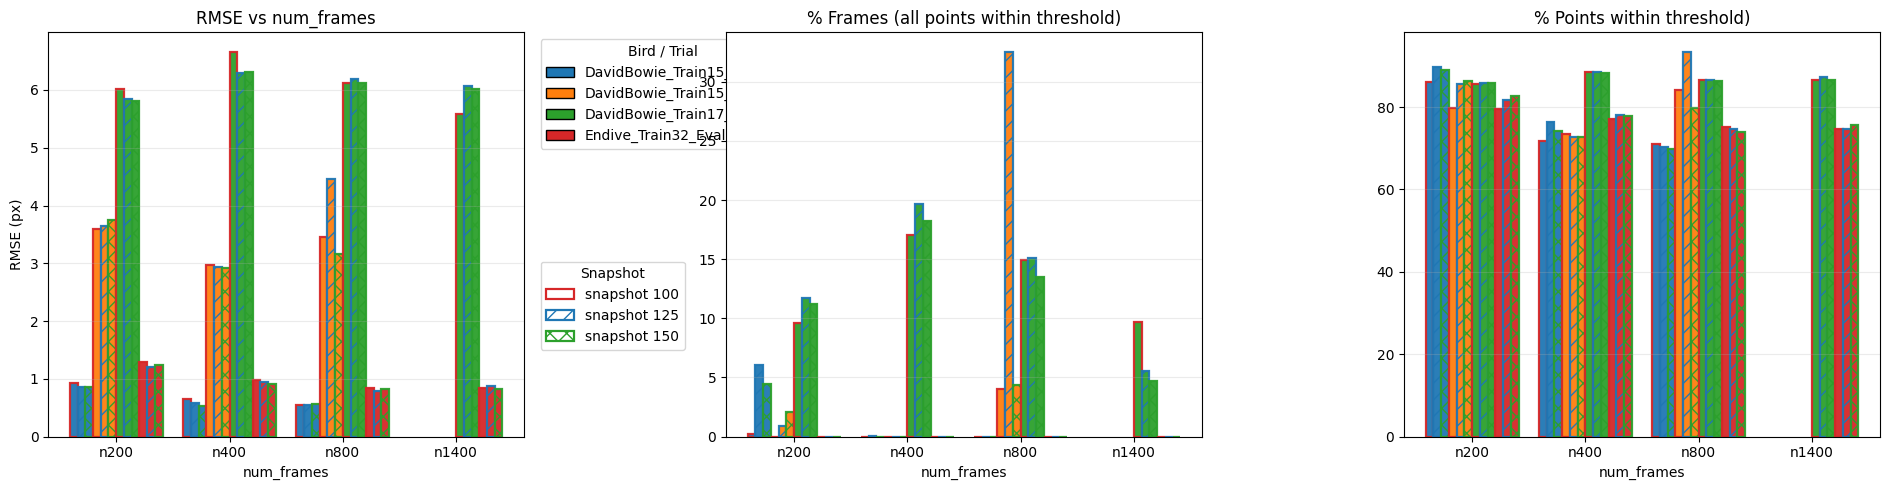

Saved RMSE vs Likelihood plot to C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\rmse_vs_likelihood.png


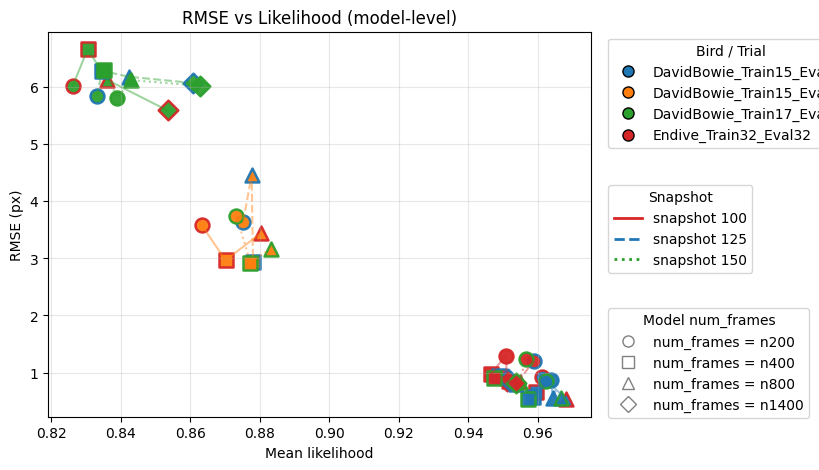

In [240]:
combined_analysis_route = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL")
# ----------------------------
# Plots: model type comparisons (snapshot-aware)
# ----------------------------
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df = summary_df.copy()

# Normalize expected columns from your summary schema
# summary_df has: Bird, train_trial, eval_trial, numframes, snapshot_num, rmse_px, ...
df["Bird_Trial"] = (
    df["bird"].astype(str)
    + "_Train"
    + df["train_trial"].astype(str)
    + "_Eval"
    + df["eval_trial"].astype(str)
)

df["num_frames"] = "n" + df["numframes"].astype(int).astype(str)
frame_order = ["n200", "n400", "n800", "n1400"]
df["num_frames"] = pd.Categorical(df["num_frames"], categories=frame_order, ordered=True)

snapshots = sorted(df["snapshot_num"].dropna().astype(int).unique().tolist())
snapshot_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c"}  # outline color
snapshot_hatch = {100: "", 125: "//", 150: "xx"}                  # bar texture
snapshot_ls = {100: "-", 125: "--", 150: ":"}                     # line type

groups = sorted(df["Bird_Trial"].unique())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

x = np.arange(len(frame_order))
n_combo = max(len(groups) * len(snapshots), 1)
bar_width = 0.82 / n_combo

# ---- grouped bars: color = Bird_Trial, outline/hatch = snapshot ----
for gi, g in enumerate(groups):
    for si, snap in enumerate(snapshots):
        sub = (
            df[(df["Bird_Trial"] == g) & (df["snapshot_num"].astype(int) == int(snap))]
            .set_index("num_frames")
            .reindex(frame_order)
        )

        combo_idx = gi * len(snapshots) + si
        offset = (combo_idx - (n_combo - 1) / 2) * bar_width

        bar_kwargs = dict(
            width=bar_width,
            color=group_color[g],
            edgecolor=snapshot_edge.get(int(snap), "black"),
            linewidth=1.6,
            hatch=snapshot_hatch.get(int(snap), ""),
            alpha=0.95,
        )

        axes[0].bar(x + offset, sub["rmse_px"], **bar_kwargs)
        axes[1].bar(x + offset, sub["percent_frames_all_points_within_threshold"], **bar_kwargs)
        axes[2].bar(x + offset, sub["percent_points_within_threshold"], **bar_kwargs)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(frame_order)
    ax.set_xlabel("num_frames")
    ax.grid(True, axis="y", alpha=0.25)

axes[0].set_title("RMSE vs num_frames")
axes[0].set_ylabel("RMSE (px)")
axes[1].set_title("% Frames (all points within threshold)")
axes[2].set_title("% Points within threshold)")

# Legends: one for Bird_Trial fills, one for snapshot outlines
bird_handles = [
    Patch(facecolor=group_color[g], edgecolor="black", label=g) for g in groups
]
snap_handles = [
    Patch(
        facecolor="white",
        edgecolor=snapshot_edge.get(int(s), "black"),
        hatch=snapshot_hatch.get(int(s), ""),
        linewidth=1.6,
        label=f"snapshot {int(s)}",
    )
    for s in snapshots
]

leg1 = axes[0].legend(handles=bird_handles, title="Bird / Trial", loc="upper left", bbox_to_anchor=(1.02, 1.0))
axes[0].add_artist(leg1)
axes[0].legend(handles=snap_handles, title="Snapshot", loc="upper left", bbox_to_anchor=(1.02, 0.45))

plt.tight_layout()
save_path = combined_analysis_route / "model_snapshot_comparison_bars.png"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved model comparison bar plot to {save_path}")
plt.show()


# ---- RMSE vs likelihood: fill color = Bird_Trial, outline/linetype = snapshot, shape = num_frames ----
plt.figure(figsize=(7, 5))
marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

for g in groups:
    for snap in snapshots:
        sub = df[(df["Bird_Trial"] == g) & (df["snapshot_num"].astype(int) == int(snap))].copy()
        if sub.empty:
            continue

        # Optional connecting line (linetype = snapshot)
        sub_line = sub.sort_values("mean_likelihood")
        plt.plot(
            sub_line["mean_likelihood"],
            sub_line["rmse_px"],
            linestyle=snapshot_ls.get(int(snap), "-"),
            color=group_color[g],
            alpha=0.45,
            linewidth=1.5,
        )

        # Points (outline color = snapshot)
        for _, r in sub.iterrows():
            plt.scatter(
                r["mean_likelihood"],
                r["rmse_px"],
                marker=marker_map.get(str(r["num_frames"]), "o"),
                s=100,
                facecolors=[group_color[g]],
                edgecolors=[snapshot_edge.get(int(snap), "black")],
                linewidths=1.8,
                alpha=0.95,
            )

plt.xlabel("Mean likelihood")
plt.ylabel("RMSE (px)")
plt.title("RMSE vs Likelihood (model-level)")
plt.grid(True, alpha=0.3)

# ...existing code...

# Build num_frames legend entries from values actually present in df
observed_numframes = sorted(
    {str(v) for v in df["num_frames"].dropna().astype(str)},
    key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
)

bird_line_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=group_color[g],
        markeredgecolor="black",
        markersize=8,
        label=g,
    )
    for g in groups
]

snap_line_handles = [
    Line2D(
        [0], [0],
        color=snapshot_edge.get(int(s), "black"),
        linestyle=snapshot_ls.get(int(s), "-"),
        linewidth=2,
        label=f"snapshot {int(s)}",
    )
    for s in snapshots
]

numframes_handles = [
    Line2D(
        [0], [0],
        marker=marker_map.get(nf, "o"),
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="gray",
        color="gray",
        markersize=8,
        label=f"num_frames = {nf}",
    )
    for nf in observed_numframes
]

ax = plt.gca()
legend1 = ax.legend(
    handles=bird_line_handles,
    title="Bird / Trial",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
)
ax.add_artist(legend1)

legend2 = ax.legend(
    handles=snap_line_handles,
    title="Snapshot",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.62),
    frameon=True,
)
ax.add_artist(legend2)

ax.legend(
    handles=numframes_handles,
    title="Model num_frames",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.30),
    frameon=True,
)

# ...existing code...
save_path = combined_analysis_route / "rmse_vs_likelihood.png"
plt.savefig(save_path, bbox_inches="tight")
print(f"Saved RMSE vs Likelihood plot to {save_path}")
plt.show()


In [241]:
# ----------------------------
# Exports
# ----------------------------

exports_root = TESTING_ROOT / "DeepLabCut" / "DB_END_COMBINED_EVAL"
exports_root.mkdir(parents=True, exist_ok=True)

run_manifest_csv = exports_root / "subepochs_run_manifest.csv"
summary_csv = exports_root / "subepochs_summary.csv"
errors_csv = exports_root / "subepochs_errors.csv"

if 'run_results_df' in globals() and not run_results_df.empty:
    run_results_df.to_csv(run_manifest_csv, index=False)
    print(f"Wrote run manifest: {run_manifest_csv}")

if 'summary_df' in globals() and not summary_df.empty:
    summary_df.to_csv(summary_csv, index=False)
    print(f"Wrote summary: {summary_csv}")

if 'errors_df' in globals() and not errors_df.empty:
    errors_df.to_csv(errors_csv, index=False)
    print(f"Wrote errors: {errors_csv}")

Wrote run manifest: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\subepochs_run_manifest.csv
Wrote summary: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\subepochs_summary.csv
Wrote errors: c:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\subepochs_errors.csv


# --------------------------------------------------------- 

# Comparison with full training

In [242]:
# ----------------------------
# Comparison with full training (interactive)
# ----------------------------
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

FULL_SUMMARY_PATH = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL\combined_summary.csv"
)

def _first_existing_col(df: pd.DataFrame, names: list[str]) -> str | None:
    for n in names:
        if n in df.columns:
            return n
    return None

def _normalize_eval_df(df: pd.DataFrame, default_epoch: int | None = None, source_label: str = "unknown") -> pd.DataFrame:
    d = df.copy()

    # Canonical columns (best effort)
    col_bird = _first_existing_col(d, ["bird", "Bird"])
    col_tt   = _first_existing_col(d, ["train_trial", "TrainTrial", "trainTrial"])
    col_et   = _first_existing_col(d, ["eval_trial", "EvalTrial", "evalTrial"])
    col_nf   = _first_existing_col(d, ["numframes", "num_frames", "NumFrames"])
    col_bt   = _first_existing_col(d, ["Bird_Trial", "bird_trial"])
    col_ep   = _first_existing_col(d, ["train_epoch", "epoch", "epochs", "snapshot_num", "snapshot"])

    # remove spaces from bird column values
    if col_bird is not None:
        d[col_bird] = (
            d[col_bird]
            .astype(str)
            .str.strip()
            .str.replace(r"\s+", "", regex=True)
            .str.lower()
        )

    # Build/repair Bird_Trial
    if col_bt is None:
        if all(c is not None for c in [col_bird, col_tt, col_et]):
            d["Bird_Trial"] = (
                d[col_bird].astype(str)
                + "_Train"
                + pd.to_numeric(d[col_tt], errors="coerce").astype("Int64").astype(str)
                + "_Eval"
                + pd.to_numeric(d[col_et], errors="coerce").astype("Int64").astype(str)
            )
        else:
            d["Bird_Trial"] = "Unknown"
    else:
        d["Bird_Trial"] = d[col_bt].astype(str)

    # numframes to numeric
    if col_nf is not None:
        if col_nf == "num_frames":
            d["numframes"] = d[col_nf].astype(str).str.extract(r"(\d+)")[0]
        else:
            d["numframes"] = d[col_nf]
    else:
        d["numframes"] = np.nan
    d["numframes"] = pd.to_numeric(d["numframes"], errors="coerce")

    # epoch to numeric
    if col_ep is not None:
        d["train_epoch"] = pd.to_numeric(d[col_ep], errors="coerce")
    else:
        d["train_epoch"] = np.nan

    if default_epoch is not None:
        d["train_epoch"] = d["train_epoch"].fillna(default_epoch)

    d["train_epoch"] = pd.to_numeric(d["train_epoch"], errors="coerce").astype("Int64")
    d["source"] = source_label

    # Keep expected metrics if present
    for m in [
        "rmse_px",
        "percent_frames_all_points_within_threshold",
        "percent_points_within_threshold",
        "mean_likelihood",
    ]:
        if m not in d.columns:
            d[m] = np.nan

    keep = [
        "Bird_Trial",
        "numframes",
        "train_epoch",
        "source",
        "rmse_px",
        "percent_frames_all_points_within_threshold",
        "percent_points_within_threshold",
        "mean_likelihood",
    ]
    return d[keep].copy()

# Current notebook results (sub-200 snapshots)
if "summary_df" not in globals() or summary_df.empty:
    raise ValueError("summary_df is missing or empty. Run evaluation cells first.")

sub_df_norm = _normalize_eval_df(summary_df, default_epoch=None, source_label="subepoch")

# Full training (200 epochs)
if not FULL_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing file: {FULL_SUMMARY_PATH}")
full_raw = pd.read_csv(FULL_SUMMARY_PATH)
full_df_norm = _normalize_eval_df(full_raw, default_epoch=200, source_label="full")

compare_df = pd.concat([sub_df_norm, full_df_norm], ignore_index=True)
compare_df = compare_df.dropna(subset=["Bird_Trial", "numframes", "train_epoch"])
compare_df["numframes"] = compare_df["numframes"].astype(int)
compare_df["train_epoch"] = compare_df["train_epoch"].astype(int)

# Widgets
epoch_options = sorted(compare_df["train_epoch"].dropna().unique().tolist())
bird_options = sorted(compare_df["Bird_Trial"].dropna().unique().tolist())

epoch_w = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)
bird_w = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)


In [243]:
# ...existing code...
import ipywidgets as widgets
from IPython.display import display

def _plot_compare(selected_epochs, selected_birds, plot_mode):
    sdf = compare_df[
        compare_df["train_epoch"].isin(list(selected_epochs))
        & compare_df["Bird_Trial"].isin(list(selected_birds))
    ].copy()

    if sdf.empty:
        print("No rows match current filters.")
        return

    metric_map = {
        "RMSE (px)": "rmse_px",
        "% Frames within threshold": "percent_frames_all_points_within_threshold",
        "% Points within threshold": "percent_points_within_threshold",
    }

    # ---- Single line-plot modes ----
    if plot_mode in metric_map:
        mcol = metric_map[plot_mode]
        subm = sdf.dropna(subset=[mcol, "numframes"])
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))

        if subm.empty:
            ax.set_title(f"{plot_mode} (no data)")
            ax.grid(True, alpha=0.3)
        else:
            sns.lineplot(
                data=subm,
                x="numframes",
                y=mcol,
                hue="Bird_Trial",
                style="train_epoch",
                markers=True,
                dashes=True,
                estimator="mean",
                errorbar=None,
                ax=ax,
            )
            ax.set_title(plot_mode)
            ax.set_xlabel("numframes")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        return

    # ---- Single scatter mode ----
    if plot_mode == "RMSE vs Likelihood":
        sc = sdf.dropna(subset=["mean_likelihood", "rmse_px"])
        fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))

        if sc.empty:
            ax.set_title("RMSE vs Likelihood (no data)")
            ax.grid(True, alpha=0.3)
        else:
            sns.scatterplot(
                data=sc,
                x="mean_likelihood",
                y="rmse_px",
                hue="Bird_Trial",
                style="train_epoch",
                size="numframes",
                sizes=(50, 180),
                alpha=0.9,
                ax=ax,
            )
            ax.set_title("RMSE vs Likelihood (model-level)")
            ax.set_xlabel("Mean likelihood")
            ax.set_ylabel("RMSE (px)")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        return

   

# widgets
epoch_options = sorted(compare_df["train_epoch"].dropna().unique().tolist())
bird_options = sorted(compare_df["Bird_Trial"].dropna().unique().tolist())

epoch_w = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

plot_w = widgets.Dropdown(
    options=[
        "RMSE (px)",
        "% Frames within threshold",
        "% Points within threshold",
        "RMSE vs Likelihood",
        "All (4 panels)",
    ],
    value="RMSE (px)",
    description="Plot",
    layout=widgets.Layout(width="320px"),
)

ui = widgets.VBox([widgets.HBox([epoch_w, bird_w]), plot_w])
out = widgets.interactive_output(
    _plot_compare,
    {"selected_epochs": epoch_w, "selected_birds": bird_w, "plot_mode": plot_w},
)
display(ui, out)
# ...existing code...

Output()

In [244]:
df_plot = compare_df.copy()
df_plot['Bird_Trial'].unique()

array(['davidbowie_Train15_Eval15', 'davidbowie_Train15_Eval17',
       'davidbowie_Train17_Eval15', 'endive_Train32_Eval32'], dtype=object)

In [245]:
# ...existing code...
import datetime

import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

# Uses compare_df (already built from subepoch + full)
df_plot = compare_df.copy()
df_plot["num_frames"] = "n" + df_plot["numframes"].astype(int).astype(str)

marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

groups = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

epoch_options = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
bird_options = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())

# epoch border colors (train_epoch)
epoch_values_all = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
epoch_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c", 200: "#9467bd"}
for i, ep in enumerate(epoch_values_all):
    if ep not in epoch_edge:
        epoch_edge[ep] = sns.color_palette("tab10", n_colors=max(len(epoch_values_all), 1))[i]

default_save_dir = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL"

def _plot_rmse_likelihood_widget(selected_epochs, selected_birds, save_plot, save_dir, save_name):
    sdf = df_plot[
        df_plot["train_epoch"].isin(list(selected_epochs))
        & df_plot["Bird_Trial"].isin(list(selected_birds))
    ].copy()

    sdf = sdf.dropna(subset=["mean_likelihood", "rmse_px", "num_frames", "train_epoch"])
    if sdf.empty:
        print("No rows match current filters.")
        return

    plt.figure(figsize=(10, 7))

    for g in sorted(sdf["Bird_Trial"].unique()):
        for ep in sorted(sdf["train_epoch"].astype(int).unique()):
            sub = sdf[(sdf["Bird_Trial"] == g) & (sdf["train_epoch"].astype(int) == int(ep))].copy()
            if sub.empty:
                continue

            for _, r in sub.iterrows():
                point_size = 250 if int(r["train_epoch"]) == 200 else 90
                alpha = 0.95 if int(r["train_epoch"]) == 200 else 0.75
                plt.scatter(
                    r["mean_likelihood"],
                    r["rmse_px"],
                    marker=marker_map.get(str(r["num_frames"]), "o"),
                    s=point_size,
                    facecolors=[group_color[g]],
                    edgecolors=[epoch_edge.get(int(r["train_epoch"]), "black")],  # <-- epoch border color
                    
                    linewidths=2.2,
                    alpha=alpha,
                )

    plt.xlabel("Mean likelihood")
    plt.ylabel("RMSE (px)")
    plt.title("RMSE vs Likelihood (full epoch=200 shown larger)")
    plt.grid(True, alpha=0.3)

    # legends
    observed_numframes = sorted(
        {str(v) for v in sdf["num_frames"].dropna().astype(str)},
        key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
    )

    bird_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor=group_color[g], markeredgecolor="black",
               markersize=8, label=g)
        for g in sorted(sdf["Bird_Trial"].unique())
    ]

    epoch_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor=epoch_edge.get(int(ep), "black"),
               markeredgewidth=1.8, markersize=8, label=f"epoch {int(ep)}")
        for ep in sorted(sdf["train_epoch"].astype(int).unique())
    ]
    numframes_handles = [
        Line2D([0], [0], marker=marker_map.get(nf, "o"), linestyle="None",
               markerfacecolor="white", markeredgecolor="gray",
               color="gray", markersize=8, label=f"num_frames = {nf}")
        for nf in observed_numframes
    ]

    size_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor="black",
               markersize=7, label="epochs != 200"),
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor="black",
               markersize=11, label="epoch = 200 (full)"),
    ]

    ax = plt.gca()
    leg1 = ax.legend(handles=bird_handles, title="Bird / Trial",
                     loc="upper left", bbox_to_anchor=(.7, 1.0), frameon=True)
    ax.add_artist(leg1)
    
    leg2 = ax.legend(handles=epoch_handles, title="Train epoch (border)",
                     loc="upper left", bbox_to_anchor=(.7, 0.8), frameon=True)
    ax.add_artist(leg2)

    ax.legend(handles=numframes_handles, title="Model num_frames",
                     loc="upper left", bbox_to_anchor=(.7, 0.6), frameon=True)
    # ax.add_artist(leg3)

    # ax.legend(handles=size_handles, title="Point size",
    #           loc="upper left", bbox_to_anchor=(1.02, 0.30), frameon=True)

    plt.tight_layout()

    if save_plot:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        stem = save_name.strip() if str(save_name).strip() else f"rmse_vs_likelihood_widget_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        out_path = out_dir / f"{stem}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    
    plt.show()

epoch_w2 = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w2 = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

save_w = widgets.Checkbox(value=False, description="Save plot")
save_dir_w = widgets.Text(value=default_save_dir, description="Save dir", layout=widgets.Layout(width="700px"))
save_name_w = widgets.Text(value="rmse_vs_likelihood_widget", description="File name", layout=widgets.Layout(width="500px"))

ui2 = widgets.VBox([
    widgets.HBox([epoch_w2, bird_w2]),
    widgets.HBox([save_w, save_name_w]),
    save_dir_w,
])

out2 = widgets.interactive_output(
    _plot_rmse_likelihood_widget,
    {
        "selected_epochs": epoch_w2,
        "selected_birds": bird_w2,
        "save_plot": save_w,
        "save_dir": save_dir_w,
        "save_name": save_name_w,
    },
)
display(ui2, out2)

# ...existing code...

Output()

In [246]:
# ...existing code...
import datetime
import ipywidgets as widgets
from IPython.display import display
from matplotlib.lines import Line2D

df_plot = compare_df.copy()
df_plot["numframes"] = pd.to_numeric(df_plot["numframes"], errors="coerce").astype("Int64")
df_plot["num_frames"] = "n" + df_plot["numframes"].astype(str)

marker_map = {"n200": "o", "n400": "s", "n800": "^", "n1400": "D"}

groups = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
palette = sns.color_palette("tab10", n_colors=max(len(groups), 1))
group_color = {g: palette[i] for i, g in enumerate(groups)}

epoch_options = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
bird_options = sorted(df_plot["Bird_Trial"].dropna().unique().tolist())
numframes_options = sorted(df_plot["numframes"].dropna().astype(int).unique().tolist())  # ints

epoch_values_all = sorted(df_plot["train_epoch"].dropna().astype(int).unique().tolist())
epoch_edge = {100: "#d62728", 125: "#1f77b4", 150: "#2ca02c", 200: "#9467bd"}
for i, ep in enumerate(epoch_values_all):
    if ep not in epoch_edge:
        epoch_edge[ep] = sns.color_palette("tab10", n_colors=max(len(epoch_values_all), 1))[i]

default_save_dir = r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCut\DB_END_COMBINED_EVAL"

def _plot_rmse_likelihood_widget(selected_epochs, selected_birds, selected_nframes, save_plot, save_dir, save_name):
    sdf = df_plot[
        df_plot["train_epoch"].isin(list(selected_epochs))
        & df_plot["Bird_Trial"].isin(list(selected_birds))
        & df_plot["numframes"].astype(int).isin(list(selected_nframes))   # now same type
    ].copy()

    sdf = sdf.dropna(subset=["mean_likelihood", "rmse_px", "num_frames", "train_epoch"])
    if sdf.empty:
        print("No rows match current filters.")
        return

    plt.figure(figsize=(11, 7))

    for g in sorted(sdf["Bird_Trial"].unique()):
        for ep in sorted(sdf["train_epoch"].astype(int).unique()):
            sub = sdf[(sdf["Bird_Trial"] == g) & (sdf["train_epoch"].astype(int) == int(ep))].copy()
            if sub.empty:
                continue

            for _, r in sub.iterrows():
                point_size = 250 if int(r["train_epoch"]) == 200 else 90
                alpha = 0.95 if int(r["train_epoch"]) == 200 else 0.75
                plt.scatter(
                    r["mean_likelihood"],
                    r["rmse_px"],
                    marker=marker_map.get(str(r["num_frames"]), "o"),
                    s=point_size,
                    facecolors=[group_color[g]],
                    edgecolors=[epoch_edge.get(int(r["train_epoch"]), "black")],
                    linewidths=2.2,
                    alpha=alpha,
                )

    plt.xlabel("Mean likelihood")
    plt.ylabel("RMSE (px)")
    plt.title("RMSE vs Likelihood (full epoch=200 shown larger)")
    plt.grid(True, alpha=0.3)

    observed_numframes = sorted(
        {str(v) for v in sdf["num_frames"].dropna().astype(str)},
        key=lambda s: int(s[1:]) if s.startswith("n") and s[1:].isdigit() else 10**9,
    )

    bird_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor=group_color[g], markeredgecolor="black",
               markersize=8, label=g)
        for g in sorted(sdf["Bird_Trial"].unique())
    ]

    epoch_handles = [
        Line2D([0], [0], marker="o", linestyle="None",
               markerfacecolor="white", markeredgecolor=epoch_edge.get(int(ep), "black"),
               markeredgewidth=1.8, markersize=8, label=f"epoch {int(ep)}")
        for ep in sorted(sdf["train_epoch"].astype(int).unique())
    ]

    numframes_handles = [
        Line2D([0], [0], marker=marker_map.get(nf, "o"), linestyle="None",
               markerfacecolor="white", markeredgecolor="gray",
               color="gray", markersize=8, label=f"num_frames = {nf}")
        for nf in observed_numframes
    ]
    ax = plt.gca()
    leg1 = ax.legend(handles=bird_handles, title="Bird / Trial",
                     loc="upper left", bbox_to_anchor=(.7, 1.0), frameon=True)
    ax.add_artist(leg1)
    
    leg2 = ax.legend(handles=epoch_handles, title="Train epoch (border)",
                     loc="upper left", bbox_to_anchor=(.7, 0.8), frameon=True)
    ax.add_artist(leg2)

    ax.legend(handles=numframes_handles, title="Model num_frames",
                     loc="upper left", bbox_to_anchor=(.7, 0.6), frameon=True)
    fig.subplots_adjust(right=0.68)

    if save_plot:
        out_dir = Path(save_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        stem = save_name.strip() if str(save_name).strip() else f"rmse_vs_likelihood_widget_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
        out_path = out_dir / f"{stem}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()

epoch_w2 = widgets.SelectMultiple(
    options=epoch_options,
    value=tuple(epoch_options),
    description="Epochs",
    layout=widgets.Layout(width="260px", height="170px"),
)

bird_w2 = widgets.SelectMultiple(
    options=bird_options,
    value=tuple(bird_options),
    description="Bird_Trial",
    layout=widgets.Layout(width="420px", height="170px"),
)

nframes_w2 = widgets.SelectMultiple(
    options=numframes_options,                
    value=tuple(numframes_options),
    description="numframes",
    layout=widgets.Layout(width="220px", height="170px"),
)

save_w = widgets.Checkbox(value=False, description="Save plot")
save_dir_w = widgets.Text(value=default_save_dir, description="Save dir", layout=widgets.Layout(width="700px"))
save_name_w = widgets.Text(value="rmse_vs_likelihood_subepochComp", description="File name", layout=widgets.Layout(width="500px"))

ui2 = widgets.VBox([
    widgets.HBox([epoch_w2, bird_w2, nframes_w2]),
    widgets.HBox([save_w, save_name_w]),
    save_dir_w,
])

out2 = widgets.interactive_output(
    _plot_rmse_likelihood_widget,
    {
        "selected_epochs": epoch_w2,
        "selected_birds": bird_w2,
        "selected_nframes": nframes_w2,
        "save_plot": save_w,
        "save_dir": save_dir_w,
        "save_name": save_name_w,
    },
)

display(ui2, out2)
# ...existing code...

Output()